# Homework 1

Through this homework, you'll practice the basics of data cleaning, data partition, data normalization, and data visualization.

Please enter the code along with your comments in the **TODO** sections.

Please refer to the **Hint** section if you do not know where to start.

Alternative solutions are totally welcomed.

## Part 1: Data cleaning and pre-processing

### Problem 1 (15 points) ##

Glass Identification Data

Source: https://archive.ics.uci.edu/ml/datasets/glass+identification

Creator: B. German

    Central Research Establishment

    Home Office Forensic Science Service

    Aldermaston, Reading, Berkshire RG7 4PN

Donor: Vina Spiehler, Ph.D., DABFT

    Diagnostic Products Corporation

In [ ]:
!pip install --upgrade openpyxl

In [2]:
import pandas as pd
import numpy as np

In [ ]:
# from google.colab import files
# file = files.upload()  #upload file into google colab session
# df = pd.read_excel("Glass_Identification_Data.xlsx")
# df.head()

Saving Glass_Identification_Data.xlsx to Glass_Identification_Data.xlsx


,ID,RI,Na,Mg,Al,Si,K,CA,Ba,Fe,Class
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,NaN,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,NaN,0.0,1
2,3,NaN,13.53,3.55,1.54,72.99,0.39,7.78,NaN,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,NaN,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,NaN,0.0,1


In [3]:
df = pd.read_excel("Glass_Identification_Data.xlsx")
df.head(5)

,ID,RI,Na,Mg,Al,Si,K,CA,Ba,Fe,Class
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,NaN,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,NaN,0.0,1
2,3,NaN,13.53,3.55,1.54,72.99,0.39,7.78,NaN,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,NaN,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,NaN,0.0,1


**TODO1:**
*   Count the the **percentage** of null/missing values for each variable
*   Drop the variables which have more than 75% missing values *(Avoid manual intervention. Code should work even if the attribute/data changes)*

In [4]:
missing_values = df.isnull().sum()

In [5]:
def calculate_percentage(df,missing_values):
    percentage = (missing_values/len(df))*100
    return percentage

calculate_percentage(df,missing_values)

ID        0.000000
RI        0.934579
Na        0.934579
Mg        7.943925
Al        0.000000
Si        0.467290
K         2.336449
CA        0.000000
Ba       78.037383
Fe        0.000000
Class     0.000000
dtype: float64

In [6]:
cols = ['Ba']
df.drop(columns=cols,inplace=True)

In [7]:
df.isna().sum()

ID        0
RI        2
Na        2
Mg       17
Al        0
Si        1
K         5
CA        0
Fe        0
Class     0
dtype: int64

**Hint:**

[Handle missing data in Python](https://machinelearningmastery.com/handle-missing-data-python/)

[dropna() thresh option](https://www.plus2net.com/python/pandas-dataframe-dropna-thresh.php)

Note: You can try other methods as well apart from the ones mentioned in the hint


**TODO2:**
*    If a variable contains more than 10 missing records, impute the records by using the mean value of records from the respective class instead of using the mean value of the entire column. *(Avoid manual intervention. Code should work even if the attribute/data changes)*
*   If a variable contains less than 10 missing records, impute the records with the previous non-NAN value from a row with the same 'Class' *(Avoid manual intervention. Code should work even if the attribute/data changes)*
* [What is imputation in Data Mining?](https://www.analyticsvidhya.com/blog/2021/06/defining-analysing-and-implementing-imputation-techniques/)

In [8]:
def impute_lessthan_10(df,cols_below_10:list):
    for col in cols_below_10:
        df[col] = df[col].ffill()
        
def impute_greaterthan_10(df,cols_above_10:list):
    for col in cols_above_10:
        df[col] = df[col].fillna(df[col].mean())
        
cols_below_10 = ['RI','Na','Si','K']
cols_above_10 = ['Mg']

In [9]:
impute_lessthan_10(df,cols_below_10)
impute_greaterthan_10(df,cols_above_10)

**Hint:** Consider using one or a combinition of [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.fillna.html), [groupby](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html), [transform](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.groupby.DataFrameGroupBy.transform.html), and [mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) to compete this task

**TODO3:** Check if all the missing values are handled

In [10]:
df.isna().sum()

ID       0
RI       0
Na       0
Mg       0
Al       0
Si       0
K        0
CA       0
Fe       0
Class    0
dtype: int64

**Hint:** If you have done all the above mentioned steps properly, you shouldnt be getting NAN values

**TODO4:** Get the descriptive statistics of the predictors for each class and present the information in a table/matrix format

Also, what will you do if your data has non-numerical columns. How will you generate the summary for all columns of a DataFrame regardless of data type?

In [11]:
df.describe(include='all')

,ID,RI,Na,Mg,Al,Si,K,CA,Fe,Class
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518376,13.421495,2.898782,1.444907,72.652103,0.502336,8.956963,0.057009,2.780374
std,61.920648,0.003032,0.816412,1.222345,0.499270,0.775808,0.649717,1.423153,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,1.000000
25%,54.250000,1.516550,12.930000,2.898782,1.190000,72.280000,0.132500,8.240000,0.000000,1.000000
50%,107.500000,1.517680,13.305000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,2.000000
75%,160.750000,1.519157,13.860000,3.600000,1.630000,73.087500,0.610000,9.172500,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,0.510000,7.000000


Summary can be Generated by using the describe(include='all) function

**Hint:** [How to calculate summary statistics with Pandas? ](https://www.w3resource.com/pandas/dataframe/dataframe-describe.php)

### Problem 2 (20 points) ##

In [12]:
#Import the built-in Titanic dataset for this problem
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

**TODO1:** What is the mean age of female and male survivors respectively?

In [14]:
Mean_survived = titanic[titanic['alive']=='yes'].groupby('sex')['age'].mean()
print(Mean_survived)

sex
female    28.847716
male      27.276022
Name: age, dtype: float64


**Hint:** Apart from the aforementioned function [groupby](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html), creating a [pivot table](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) is also a way to go.

**TODO2:** Among all the survivors, what is the gender distribution? (You are expected to present the percentage of each gender in a pivot table.)

In [15]:
gender_distribution_survivors = titanic[titanic['alive'] == 'yes']['sex'].value_counts(normalize=True) * 100
print(gender_distribution_survivors)


sex
female    68.128655
male      31.871345
Name: proportion, dtype: float64


**Hint:** The [pivot table](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) can help with complex aggregation.

**TODO3:** How many children (age <= 12) survived and which class ticket they had?

In [16]:
children_survived = titanic[(titanic['alive'] == 'yes') & (titanic['age'] <= 12)]
children_survived_count = children_survived.groupby('class').size()
print(children_survived_count)

class
First      3
Second    17
Third     20
dtype: int64


/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_13889/1509639784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  children_survived_count = children_survived.groupby('class').size()


**Hint:**

[Ways to filter pandas dataframe based on column values](https://www.geeksforgeeks.org/ways-to-filter-pandas-dataframe-by-column-values/)

[Using pandas groupby count()](https://datascienceparichay.com/article/pandas-groupby-count-of-rows-in-each-group/)


**TODO4:** How many first class seated girls (children) DID NOT survive?

**TODO5:** Check whether variable 'survived' and 'alive' are consistent (contains the same information). Is there any other redundant variable existing in this dataset? Drop all the redundant variables and present the updated dataset.

In [17]:
children_not_survived = titanic[(titanic['alive'] == 'no') * (titanic['class'] == 'First')].shape[0]
print(children_not_survived)

80


**Hint:**

You might want to encode two variables to 0 and 1 with [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) and check if two columns contain the same value.

Or else you can use [Replace](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html)

**TODO6:** What other insights can you draw from this dataset? Present one finding through pivot table.

In [18]:
survival_rate = titanic.pivot_table(values='alive', index='class', columns='sex', aggfunc=lambda x: (x == 'yes').mean())
print("Survival Rate by Class and Gender:")
print(survival_rate)


average_age = titanic.pivot_table(values='age', index='class', columns='sex', aggfunc='mean')
print("\nAverage Age by Class and Gender:")
print(average_age)


passenger_count = titanic.pivot_table(values='age', index='class', columns='embark_town', aggfunc='count')
print("\nCount of Passengers by Class and Embarkation Point:")
print(passenger_count)

passenger_count = titanic.pivot_table(values='age',index='class',columns='embark_town',aggfunc='count')

Survival Rate by Class and Gender:
sex       female      male
class                     
First   0.968085  0.368852
Second  0.921053  0.157407
Third   0.500000  0.135447

Average Age by Class and Gender:
sex        female       male
class                       
First   34.611765  41.281386
Second  28.722973  30.740707
Third   21.750000  26.507589

Count of Passengers by Class and Embarkation Point:
embark_town  Cherbourg  Queenstown  Southampton
class                                          
First               74           2          108
Second              15           2          156
Third               41          24          290


## Part 2: Data Visualization

Before you start: Read the book chapter “Data Visualization”.


**Note: Please make sure your plots are complete and presentable with a title, proper axis names and legends if applicable.**

### Problem 3 (25 points)

Dataset: Forest fires

Source: https://archive.ics.uci.edu/ml/datasets/Forest+Fires

The file forestfires.csv includes data from Cortez and Morais (2007).

Number of instances and attributes are 517 and 13 respectively.  

Attribute Information:
1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the `year`: 'jan' to 'dec'
4. day - day of the week: 'mon' to 'sun'
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3
7. DC - DC index from the FWI system: 7.9 to 860.6
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40
12. rain - outside rain in mm/m2 : 0.0 to 6.4
13. area - the burned area of the forest (in ha): 0.00 to 1090.84

(this output variable is very skewed towards 0.0, thus it may make sense to model with the logarithm transform).


In [ ]:
#Importing libraries and loading the dataset 'forestfires.csv'

# import matplotlib.pyplot as plt
# import seaborn as sns

# from google.colab import files
# file = files.upload()  #upload file into google colab session
# df = pd.read_csv("forestfires.csv")
# df.head()

In [19]:
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('forestfires.csv')
df.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


**TODO1:** Plot a stacked bar chart to show the number of forest fires grouped by months and days of the week. *(Make sure the month are in Months chronological order i.e attribute values are sorted starting with January and ending with December)*

In [21]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

# Convert 'month' and 'day' columns to categorical with the specified order
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

Text(0, 0.5, 'Count of Fires')

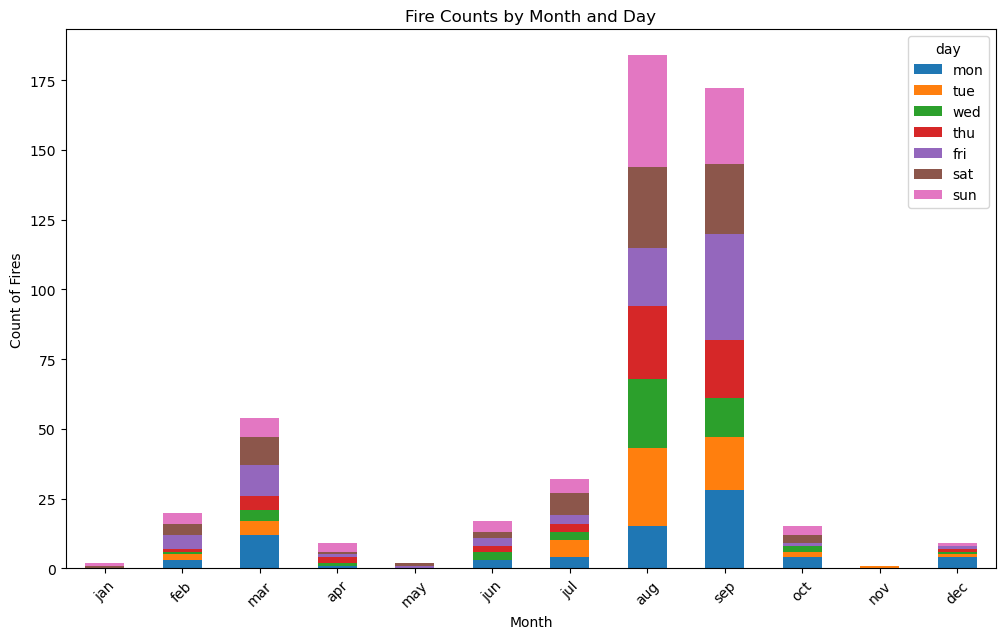

In [22]:
fire_counts = df.groupby(['month','day'],observed=False).size().unstack(fill_value=0)
fire_counts.plot(kind='bar',stacked=True,figsize=(12,7))
plt.title('Fire Counts by Month and Day')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Count of Fires')

**Hint:** Before creating the bar chart, use aforementioned data aggregation tools to transform the original dataset to the data frame you need for this section. To be more specific, you need to compute the count of forest fires by months and days before plotting.

Then [build a stacked bar chart with Pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html)

**TODO2 (not graded):** Do you notice any problem with the stacked bar chart? How do you plan to remedy this problem?

The Main Inference from the graph is the forestfires take place most in the months of August and September during the summer season. The Local authorities have to reduce fires in the forest in the months of August and September

**TODO3:** Create a scatter plot of the fires with the location(X & Y) as the X and Y axis, and the size of the point indicating the area burnt.

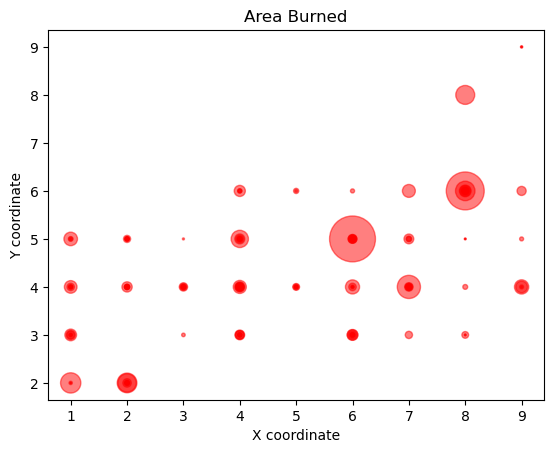

In [38]:
plt.scatter(x=df['X'],y=df['Y'],c='red',alpha=0.5,s=df['area'])
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate' )
plt.title('Area Burned')
plt.show()



**Hint:** [Build a scatter plot with Pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.scatter.html)

**TODO4:** Plot the scatter matrix for temp, RH, DC and DMC. How do you interpret the result in terms of correlation among the variables?

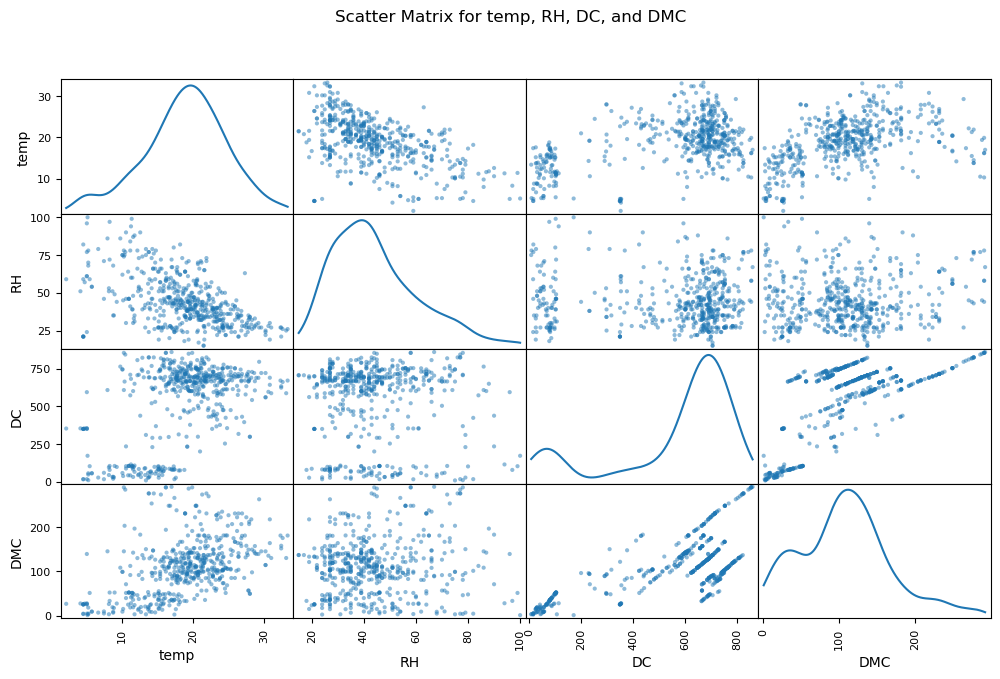

In [25]:
from pandas.plotting import scatter_matrix
columns = ['temp','RH','DC','DMC']
scatter_matrix(df[columns],figsize=(12,7),diagonal='kde')
plt.suptitle('Scatter Matrix for temp, RH, DC, and DMC')
plt.show()

**Hint:** [Creat a scatter matrix with Seaborn](https://seaborn.pydata.org/generated/seaborn.pairplot.html)

**TODO5:** Does the wind speed affect the spread of wildfire? Use visualization to back up your answer.

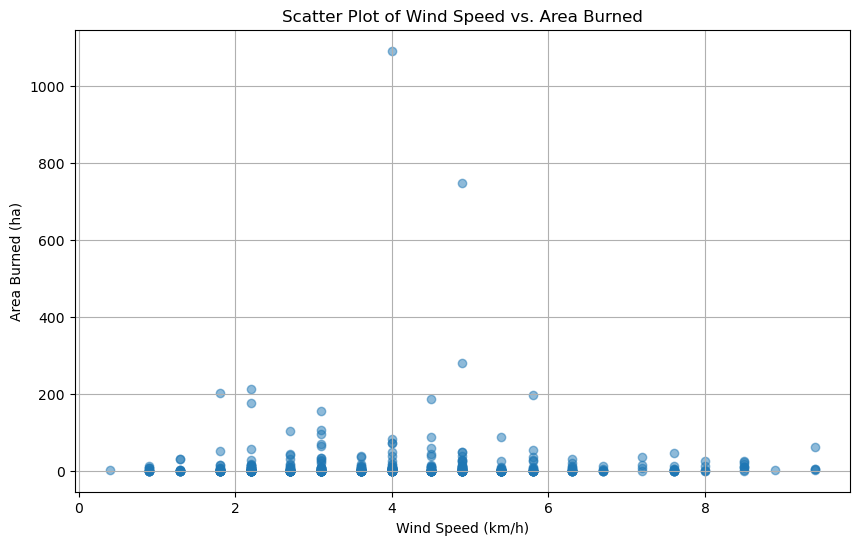

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['wind'], df['area'], alpha=0.5)
plt.title('Scatter Plot of Wind Speed vs. Area Burned')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Area Burned (ha)')
plt.grid(True)
plt.show()

### Problem 4 (20 points)


Dataset: Graduate School Admission

This dataset was created for Graduate Admissions prediction.

The purpose is to help students with shortlisting target universities according to their profiles.

The predicted output gives them a fair idea about their chances of admission for a particular university.

Attribute Information:

Serial.No.: application number: 1 to 500

GRE.Score: GRE score: 290 to 340

TOEFL.Score: TOEFL score: 92 to 120

University.Rating: undergraduate school’s rating: A to E

SOP: Statement of Purpose score: 1 to 5

LOR: Letter of Recommendation score: 1 to 5

CGPA: Undergraduate GPA: 6.8 to 9.92

Research: Research experience: Yes or No

Chance.of.Admit: Chance of getting admitted: 0.34 to 0.97

In [ ]:
# from google.colab import files
# file = files.upload()  #upload file into google colab session
# df = pd.read_csv("Admission_Predict.csv")
# df.head()

In [31]:
df1 = pd.read_csv('Admission_Predict.csv')
df1.head(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [38]:
df1.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

**TODO1:** Is LOR score related to CGPA? Use visualization to back up your answer.

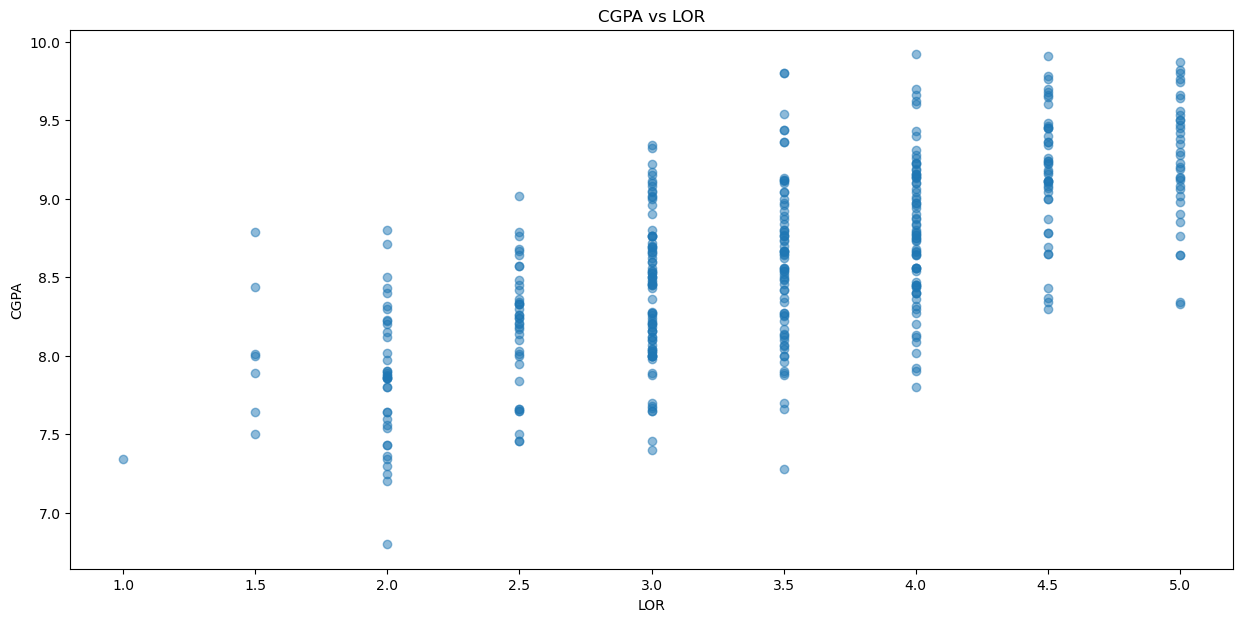

In [39]:
plt.figure(figsize=(15,7))
plt.scatter(df1['LOR '],df1['CGPA'],alpha=0.5)
plt.xlabel('LOR')
plt.ylabel('CGPA')
plt.title('CGPA vs LOR')
plt.show()

**Hint:** Use the visualization that is used to compare 2 numerical variables

**TODO2:**
*   Create a scatterplot of CGPA and GRE. Use color to indicate research experience. Interpret the plot.

*   Create a scatterplot of University.Rating vs Research. Why is the plot not useful? Pick an appropriate chart type to reveal the relationship between University.Rating and Research.


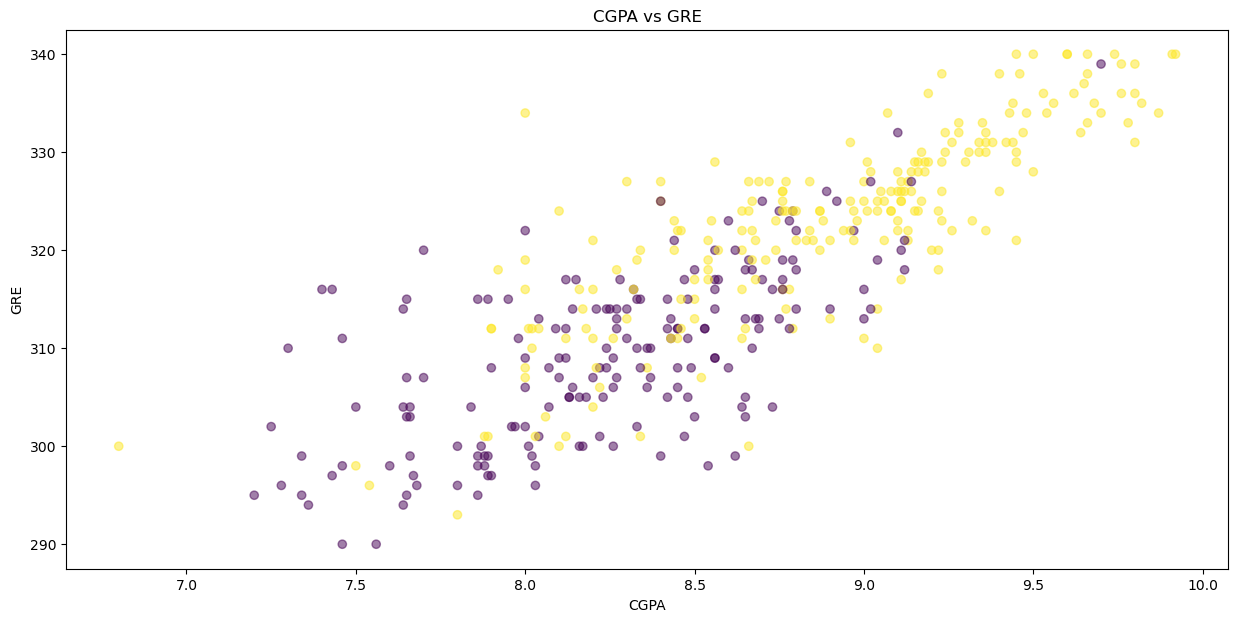

In [35]:
plt.figure(figsize=(15,7))
plt.scatter(df1['CGPA'],df1['GRE Score'],alpha=0.5,c=df1['Research'])
plt.xlabel('CGPA')
plt.ylabel('GRE')
plt.title('CGPA vs GRE')
plt.show()



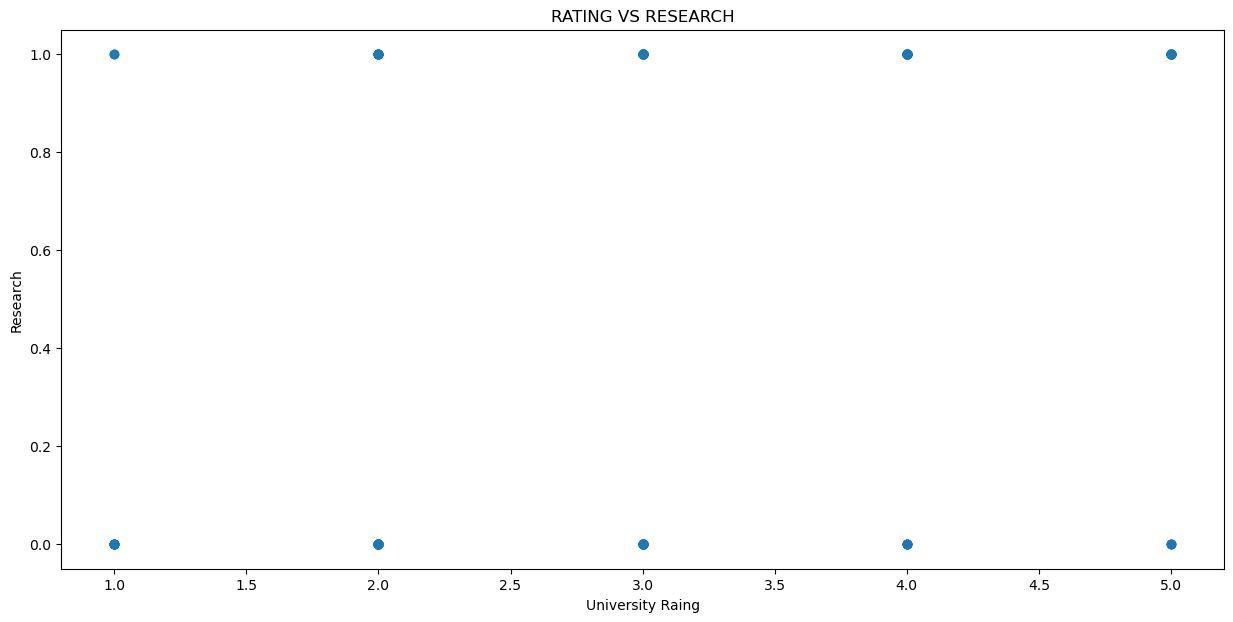

In [47]:
plt.figure(figsize=(15,7))
plt.scatter(df1['University Rating'],df1['Research'],alpha=0.5)
plt.xlabel('University Raing')
plt.ylabel('Research')
plt.title('RATING VS RESEARCH')
plt.show()

A Bar Plot would better visualize the graph

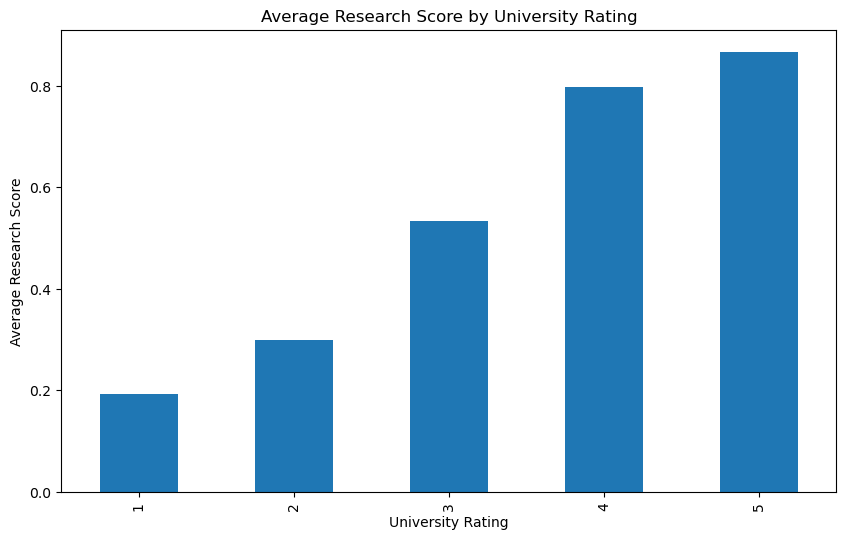

In [49]:
mean_research = df1.groupby('University Rating')['Research'].mean()


plt.figure(figsize=(10, 6))
mean_research.plot(kind='bar')
plt.xlabel('University Rating')
plt.ylabel('Average Research Score')
plt.title('Average Research Score by University Rating')
plt.show()

**TODO3:** Plot a pie chart of University Rating. The pie chart should also present the percentage of each slice. Explain your findings. *(Make sure you show data labels)*

In [41]:
df1['University Rating'].value_counts()

University Rating
3    133
2    107
4     74
5     60
1     26
Name: count, dtype: int64

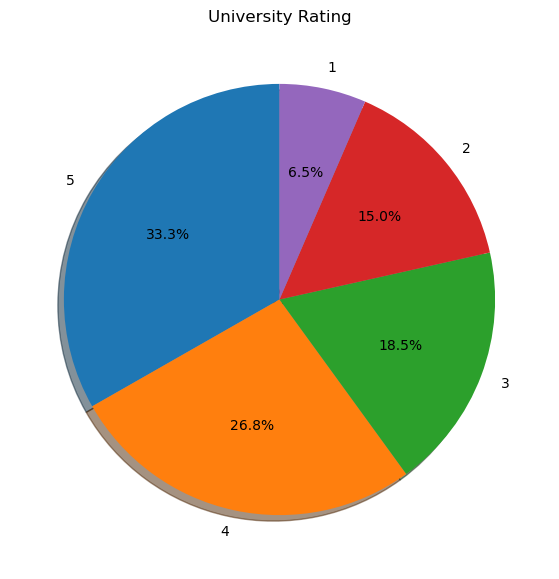

In [44]:
plt.figure(figsize=(15,7))
labels = ['5','4','3','2','1']
plt.pie(df1['University Rating'].value_counts(),labels=labels,
        autopct='%1.1f%%',shadow=True,startangle=90)
plt.title('University Rating')
plt.show()

**Hint:** [Build a pie chart with Matplotlib](https://matplotlib.org/3.1.1/gallery/pie_and_polar_charts/pie_features.html)

[Build a pie chart with Pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.pie.html)

**TODO4:** What other insights can you draw from this dataset? Present one finding with visualization.

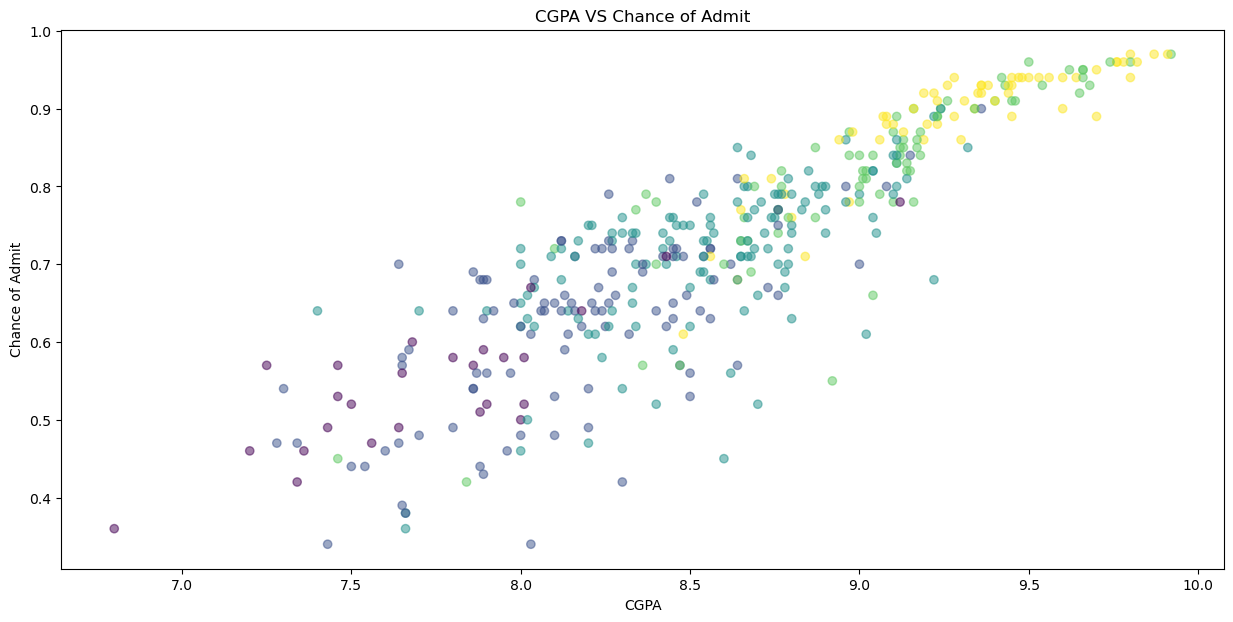

In [46]:
plt.figure(figsize=(15,7))
plt.scatter(df1['CGPA'],df1['Chance of Admit '],alpha=0.5,c=df1['University Rating'])
plt.xlabel('CGPA')
plt.ylabel('Chance of Admit')
plt.title('CGPA VS Chance of Admit')
plt.show()

This shows that the more the CGPA more is the Chance of getting admitted in the University with a higher Rating

### Problem 5 (20 points)

#### New York City Airbnb Data

Airbnb, Inc is an American company that operates an online marketplace for lodging, primarily homestays for vacation rentals, and tourism activities. Based in San Francisco, California, the platform is accessible via website and mobile app. Airbnb does not own any of the listed properties; instead, it profits by receiving commission from each booking. The company was founded in 2008. Airbnb is a shortened version of its original name, AirBedandBreakfast.com.

#### Context
The following Airbnb activity is included in this New York dataset:


Listings, including full descriptions and average review score Reviews, including unique id for each reviewer and detailed comments Calendar, including listing id and the price and availability for that day.


<b> Source: </b> https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata?resource=download


### **Objectives:**
Using the techniques you learned above, explore the dataset to answer the following questions:

1. **Explore and Summarize the Dataset**  
   - Create a summary table to understand the variable types (numeric, categorical, etc.) and basic statistics (mean, median, range, etc.).  
   - Identify patterns, anomalies, or potential issues in the dataset that might need pre-processing.

2. **Apply Pre-processing Techniques**  
   - Determine and justify the pre-processing techniques required for this dataset (e.g., handling missing values, inconsistent data, scaling, or outlier detection).  
   - Implement these techniques and explain how they improve the dataset's quality and usability.

3. **Analyze and Draw Insights**  
   - Define a stakeholder for this analysis (for example, potential Airbnb hosts, Airbnb customers, or Airbnb marketing team) and list two questions your stakeholders could ask and benefit from the insights.
   - For each question defined, create at least one graph and/or statistical analysis to share relevant insights from the given data to support your analysis.


In [134]:
df_newest = pd.read_csv('Airbnb_NY.csv')
df_newest.head()

,id,NAME,host id,host name,neighbourhood group,neighbourhood,lat,long,country,cancellation_policy,room type,Construction year,price,service fee,number of reviews,review rate number
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,strict,Private room,2020.0,$966,$193,9.0,4.0
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,moderate,Entire home/apt,2007.0,$142,$28,45.0,4.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,flexible,Private room,2005.0,$620,$124,0.0,5.0
3,1002755,NaN,85098326012,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,moderate,Entire home/apt,2005.0,$368,$74,270.0,4.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,moderate,Entire home/apt,2009.0,$204,$41,9.0,3.0


# **Hints**

### **Handling Inconsistent Data**

1. **Convert 'price' and 'service fee' to numeric**
   - Use appropriate data type conversion functions to transform these fields into numeric data types.
   - Check for any non-numeric or invalid values that might cause errors during conversion.

2. **Analyze the 'neighbourhood group' field for inconsistencies**
   - Look for misspellings, case differences, or extra spaces.
   - Normalize the data (e.g., standardize the text to lowercase, trim spaces).
   - Use appropriate functions or techniques to handle inconsistencies.

---

### **Handling Missing Values**

1. **Identify missing values**
   - Use summary statistics or visualization (e.g., heatmaps) to identify missing fields in both numeric and categorical data.
   - Check for the proportion of missing values in each column.

2. **Impute missing values for numeric columns**
   - For `price` and `service fee`: Use an imputation method based on your analysis and reasoning.

3. **Impute missing values for categorical columns**
   - Fill missing values in categorical fields with `'unknown'` to maintain consistency.

4. **Verify missing values are handled**
   - Confirm that all missing values have been appropriately addressed. Use summary statistics to recheck the data.

---

### **Identification and Handling Outliers**

1. **Identify and visualize outliers**
   - Use boxplots to detect outliers for fields like `price`, `service fee`, and `number of reviews`.
   - Examine the spread of the data and note extreme values.

2. **Determine how to handle outliers**
   - Decide whether to remove, cap, or keep the outliers based on the context and potential impact on the analysis.
   - Justify your choice: Outliers may represent valid extreme cases or errors in the data.

---

### **Data Transformation**

1. **Identify numeric features needing scaling**
   - Pinpoint columns with numeric data (e.g., `price`, `service fee`, etc.).
   - Ensure fields with varying scales are normalized to prevent biased analysis.

2. **Apply appropriate scaling or transformation methods**
   - Use scalers like MinMaxScaler, StandardScaler, or RobustScaler based on the data's distribution or appropriate transformations like log or exponential.
   - Normalize or standardize the fields depending on whether the data contains outliers.

---


**<span style="color:blue;">Note:</span> The above are just hints and examples of visualizations you can try. Whatever preprocessing, analysis, or conclusions you draw should be backed by appropriate visualizations or statistical evidence.**



In [135]:
df_newest.head(5)

,id,NAME,host id,host name,neighbourhood group,neighbourhood,lat,long,country,cancellation_policy,room type,Construction year,price,service fee,number of reviews,review rate number
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,strict,Private room,2020.0,$966,$193,9.0,4.0
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,moderate,Entire home/apt,2007.0,$142,$28,45.0,4.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,flexible,Private room,2005.0,$620,$124,0.0,5.0
3,1002755,NaN,85098326012,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,moderate,Entire home/apt,2005.0,$368,$74,270.0,4.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,moderate,Entire home/apt,2009.0,$204,$41,9.0,3.0


In [136]:
df_newest.shape

(102067, 16)

In [137]:
df_newest.describe()

,id,host id,lat,long,Construction year,number of reviews,review rate number
count,1.020670e+05,1.020670e+05,102059.000000,102059.000000,101862.000000,101884.000000,101741.000000
mean,2.910361e+07,4.925660e+10,40.728104,-73.949627,2012.488730,27.465922,3.278462
std,1.624509e+07,2.854557e+10,0.055856,0.049534,5.764909,49.505417,1.284932
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,0.000000,1.000000
25%,1.506041e+07,2.456794e+10,40.688740,-73.982575,2007.000000,1.000000,2.000000
50%,2.903774e+07,4.911839e+10,40.722280,-73.954440,2012.000000,7.000000,3.000000
75%,4.315922e+07,7.400603e+10,40.762760,-73.932340,2017.000000,30.000000,4.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1024.000000,5.000000


Handling Inconsistent Data

In [138]:
df_newest.dtypes

id                       int64
NAME                    object
host id                  int64
host name               object
neighbourhood group     object
neighbourhood           object
lat                    float64
long                   float64
country                 object
cancellation_policy     object
room type               object
Construction year      float64
price                   object
service fee             object
number of reviews      float64
review rate number     float64
dtype: object

In [139]:
df_newest.isna().sum()

id                       0
NAME                   245
host id                  0
host name              405
neighbourhood group     28
neighbourhood           14
lat                      8
long                     8
country                  0
cancellation_policy      0
room type                0
Construction year      205
price                  242
service fee            273
number of reviews      183
review rate number     326
dtype: int64

In [140]:
def remove_symbols(df_newest,columns:list):
    for col in columns:
        df_newest[col] = df_newest[col].str.replace("$","")

remove_symbols(df_newest,columns=["price","service fee"])

In [141]:
def convert_numeric(df_newest,columns:list):
    for col in columns:
        df_newest[col] = pd.to_numeric(df_newest[col], errors='coerce')
        
convert_numeric(df_newest,columns=["price","service fee"])

In [142]:
df_newest.dtypes

id                       int64
NAME                    object
host id                  int64
host name               object
neighbourhood group     object
neighbourhood           object
lat                    float64
long                   float64
country                 object
cancellation_policy     object
room type               object
Construction year      float64
price                  float64
service fee            float64
number of reviews      float64
review rate number     float64
dtype: object

In [143]:
df_newest.head(5)

,id,NAME,host id,host name,neighbourhood group,neighbourhood,lat,long,country,cancellation_policy,room type,Construction year,price,service fee,number of reviews,review rate number
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,strict,Private room,2020.0,966.0,193.0,9.0,4.0
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,moderate,Entire home/apt,2007.0,142.0,28.0,45.0,4.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,flexible,Private room,2005.0,620.0,124.0,0.0,5.0
3,1002755,NaN,85098326012,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,moderate,Entire home/apt,2005.0,368.0,74.0,270.0,4.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,moderate,Entire home/apt,2009.0,204.0,41.0,9.0,3.0


In [144]:
missing_values1 = df_newest['neighbourhood group'].value_counts()
missing_values1

neighbourhood group
Manhattan        43569
Brooklyn         41622
Queens           13205
Bronx             2694
Staten Island      947
brookln              1
manhatan             1
Name: count, dtype: int64

In [145]:
corrections = {'brookln':'Brooklyn','manhatan':'Manhattan'}

df_newest['neighbourhood group'] = df_newest['neighbourhood group'].replace(corrections)

In [146]:
df_newest['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43570
Brooklyn         41623
Queens           13205
Bronx             2694
Staten Island      947
Name: count, dtype: int64

In [147]:
df_newest.isna().sum()

id                         0
NAME                     245
host id                    0
host name                405
neighbourhood group       28
neighbourhood             14
lat                        8
long                       8
country                    0
cancellation_policy        0
room type                  0
Construction year        205
price                  18068
service fee              273
number of reviews        183
review rate number       326
dtype: int64

Handling Missing Data

In [148]:
missed = df_newest.isna().sum()
missed

id                         0
NAME                     245
host id                    0
host name                405
neighbourhood group       28
neighbourhood             14
lat                        8
long                       8
country                    0
cancellation_policy        0
room type                  0
Construction year        205
price                  18068
service fee              273
number of reviews        183
review rate number       326
dtype: int64

In [149]:
def calculate_percentage(df,missed):
    percentage = (missed/len(df))*100
    return percentage

calculate_percentage(df_newest,missed)

id                      0.000000
NAME                    0.240038
host id                 0.000000
host name               0.396798
neighbourhood group     0.027433
neighbourhood           0.013716
lat                     0.007838
long                    0.007838
country                 0.000000
cancellation_policy     0.000000
room type               0.000000
Construction year       0.200848
price                  17.702098
service fee             0.267471
number of reviews       0.179294
review rate number      0.319398
dtype: float64

In [150]:
df_newest.dtypes

id                       int64
NAME                    object
host id                  int64
host name               object
neighbourhood group     object
neighbourhood           object
lat                    float64
long                   float64
country                 object
cancellation_policy     object
room type               object
Construction year      float64
price                  float64
service fee            float64
number of reviews      float64
review rate number     float64
dtype: object

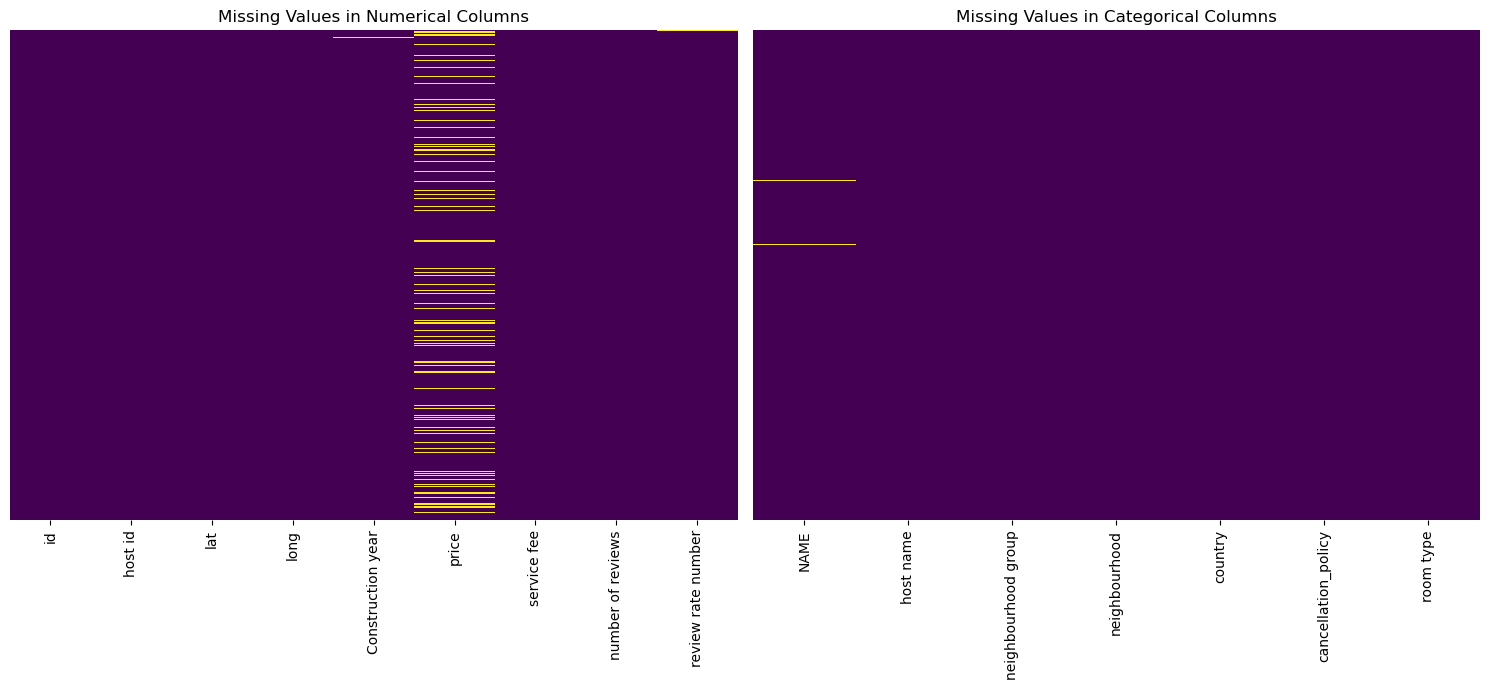

In [151]:
categorical_columns = df_newest.select_dtypes(include=['object']).columns
numerical_columns = df_newest.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
sns.heatmap(df_newest[numerical_columns].isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing Values in Numerical Columns')

plt.subplot(1,2,2)
sns.heatmap(df_newest[categorical_columns].isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing Values in Categorical Columns')

plt.tight_layout()
plt.show()

In [152]:
df_newest.dtypes

id                       int64
NAME                    object
host id                  int64
host name               object
neighbourhood group     object
neighbourhood           object
lat                    float64
long                   float64
country                 object
cancellation_policy     object
room type               object
Construction year      float64
price                  float64
service fee            float64
number of reviews      float64
review rate number     float64
dtype: object

In [153]:
df_newest.isna().sum()

id                         0
NAME                     245
host id                    0
host name                405
neighbourhood group       28
neighbourhood             14
lat                        8
long                       8
country                    0
cancellation_policy        0
room type                  0
Construction year        205
price                  18068
service fee              273
number of reviews        183
review rate number       326
dtype: int64

Filling imputed values such for price,service fee with respective means

In [154]:
df_newest['price']

0         966.0
1         142.0
2         620.0
3         368.0
4         204.0
          ...  
102062    844.0
102063    837.0
102064    988.0
102065    546.0
102066      NaN
Name: price, Length: 102067, dtype: float64

In [155]:
def impute_missing_values(df_newest,columns:list):
    for col in columns:
        df_newest[col] = df_newest[col].fillna(df_newest[col].mean())
        
def categorical_impute(df_newest,cc:list):
    for col in cc:
        df_newest[col] = df_newest[col].fillna('Unknown')
        
columns = ['price','service fee']
cc = ['NAME','host name','neighbourhood group','neighbourhood']


impute_missing_values(df_newest,columns)
categorical_impute(df_newest,cc)


In [156]:
df_newest.isna().sum()

id                       0
NAME                     0
host id                  0
host name                0
neighbourhood group      0
neighbourhood            0
lat                      8
long                     8
country                  0
cancellation_policy      0
room type                0
Construction year      205
price                    0
service fee              0
number of reviews      183
review rate number     326
dtype: int64

Rest missing values to be filled by ffill()

In [157]:
def remaining_impute(df_newest,cs:list):
    for col in cs:
        df_newest[col] = df_newest[col].ffill()
        
cs = ['Construction year','number of reviews','review rate number','lat','long']
remaining_impute(df_newest,cs)

In [158]:
df_newest.isna().sum()

id                     0
NAME                   0
host id                0
host name              0
neighbourhood group    0
neighbourhood          0
lat                    0
long                   0
country                0
cancellation_policy    0
room type              0
Construction year      0
price                  0
service fee            0
number of reviews      0
review rate number     0
dtype: int64

Identification and Handling Outliers

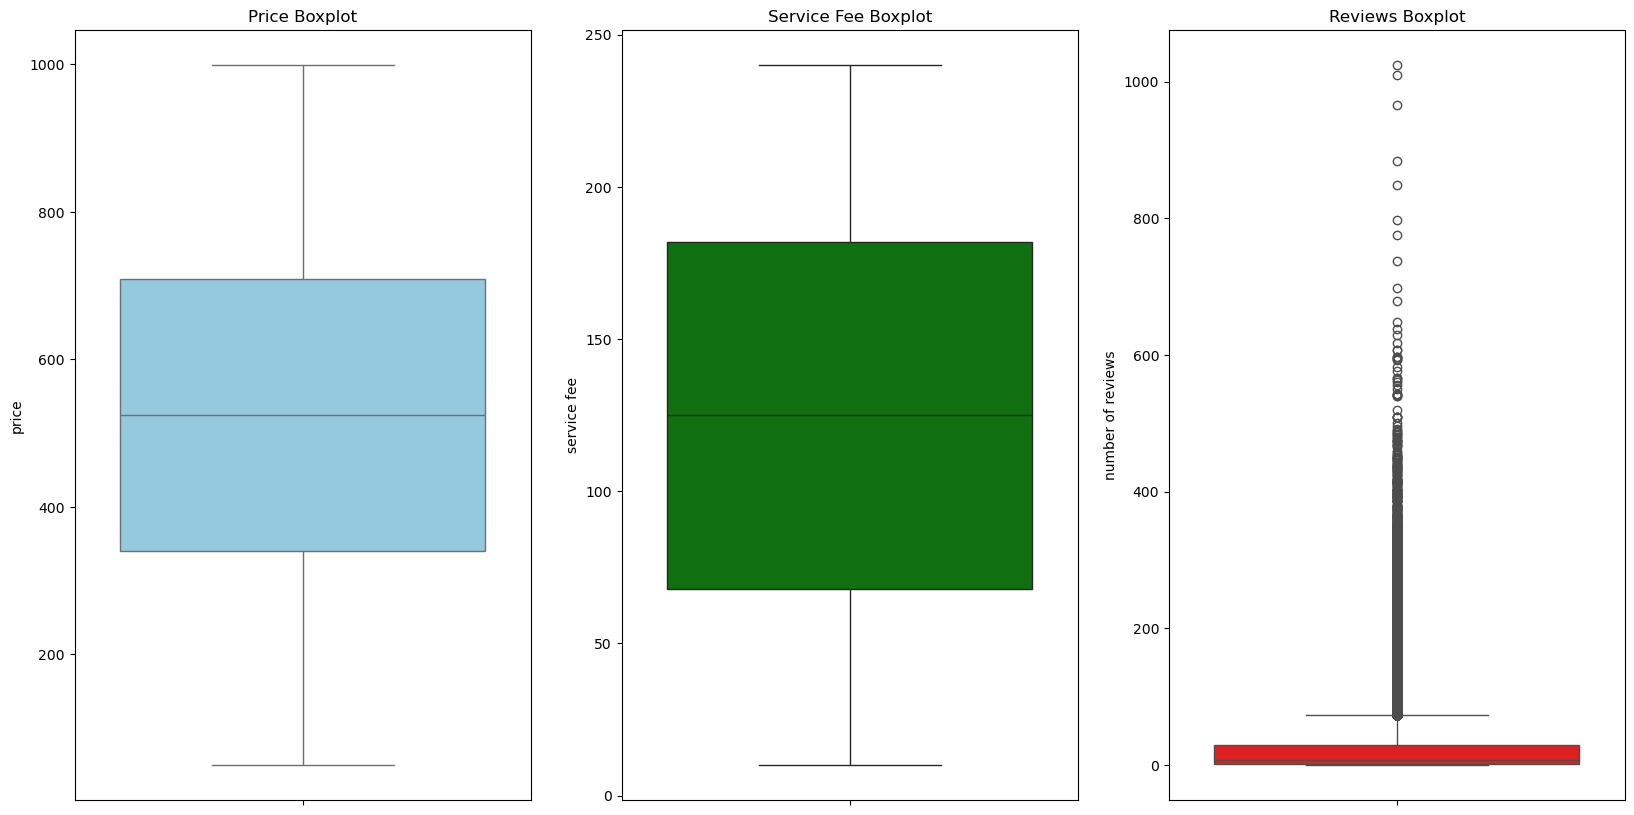

In [159]:
plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
sns.boxplot(y=df_newest['price'],color='skyblue')
plt.title('Price Boxplot')

plt.subplot(1,3,2)
sns.boxplot(y=df_newest['service fee'],color='green')
plt.title('Service Fee Boxplot')

plt.subplot(1,3,3)
sns.boxplot(y=df_newest['number of reviews'],color='red')
plt.title('Reviews Boxplot')

plt.show()

In [160]:
df_newest['number of reviews'].value_counts()

number of reviews
0.0      15816
1.0      10363
2.0       7151
3.0       5350
4.0       4126
         ...  
483.0        1
367.0        1
648.0        1
567.0        1
300.0        1
Name: count, Length: 476, dtype: int64

In [161]:
df_newwee = df_newest.copy()

In [162]:
df_newwee.shape

(102067, 16)

In [177]:
def remove_outliers(df_newwee,columns:list):
    for col in columns:
        Q1 = df_newwee[col].quantile(0.25)  
        Q3 = df_newwee[col].quantile(0.75)  
        IQR = Q3 - Q1 
        
    
        lower_bound = max(Q1 - 1.5 * IQR, 0)
        upper_bound = Q3 + 1.5 * IQR
        
        print(f"Column: {col}")
        print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
        print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        
        
        df_new_filtered = df_newwee[(df_newwee[col] >= lower_bound) & (df_newwee[col] <= upper_bound)]
        
        
        print(f"Rows before filtering: {len(df_newwee)}")
        print(f"Rows after filtering: {len(df_new_filtered)}")
        
        
        df_newwee = df_new_filtered  
    
    return df_newwee

columns = ['number of reviews']
remove_outliers(df_newwee,columns)

Column: number of reviews
Q1: 1.0, Q3: 30.0, IQR: 29.0
Lower Bound: 0, Upper Bound: 73.5
Rows before filtering: 102067
Rows after filtering: 90384


,id,NAME,host id,host name,neighbourhood group,neighbourhood,lat,long,country,cancellation_policy,room type,Construction year,price,service fee,number of reviews,review rate number
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,strict,Private room,2020.0,966.00000,193.0,9.0,4.0
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,moderate,Entire home/apt,2007.0,142.00000,28.0,45.0,4.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,flexible,Private room,2005.0,620.00000,124.0,0.0,5.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,moderate,Entire home/apt,2009.0,204.00000,41.0,9.0,3.0
6,1004650,BlissArtsSpace!,61300605564,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,moderate,Private room,2015.0,71.00000,14.0,49.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102062,6092437,Spare room in Williamsburg,12312296767,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,flexible,Private room,2003.0,844.00000,169.0,0.0,3.0
102063,6092990,Best Location near Columbia U,77864383453,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,moderate,Private room,2016.0,837.00000,167.0,1.0,2.0
102064,6093542,"Comfy, bright room in Brooklyn",69050334417,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,moderate,Private room,2009.0,988.00000,198.0,0.0,5.0
102065,6094094,Big Studio-One Stop from Midtown,11160591270,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,strict,Entire home/apt,2015.0,546.00000,109.0,5.0,3.0


In [175]:
print(df_newwee['number of reviews'].max()) 


1024.0


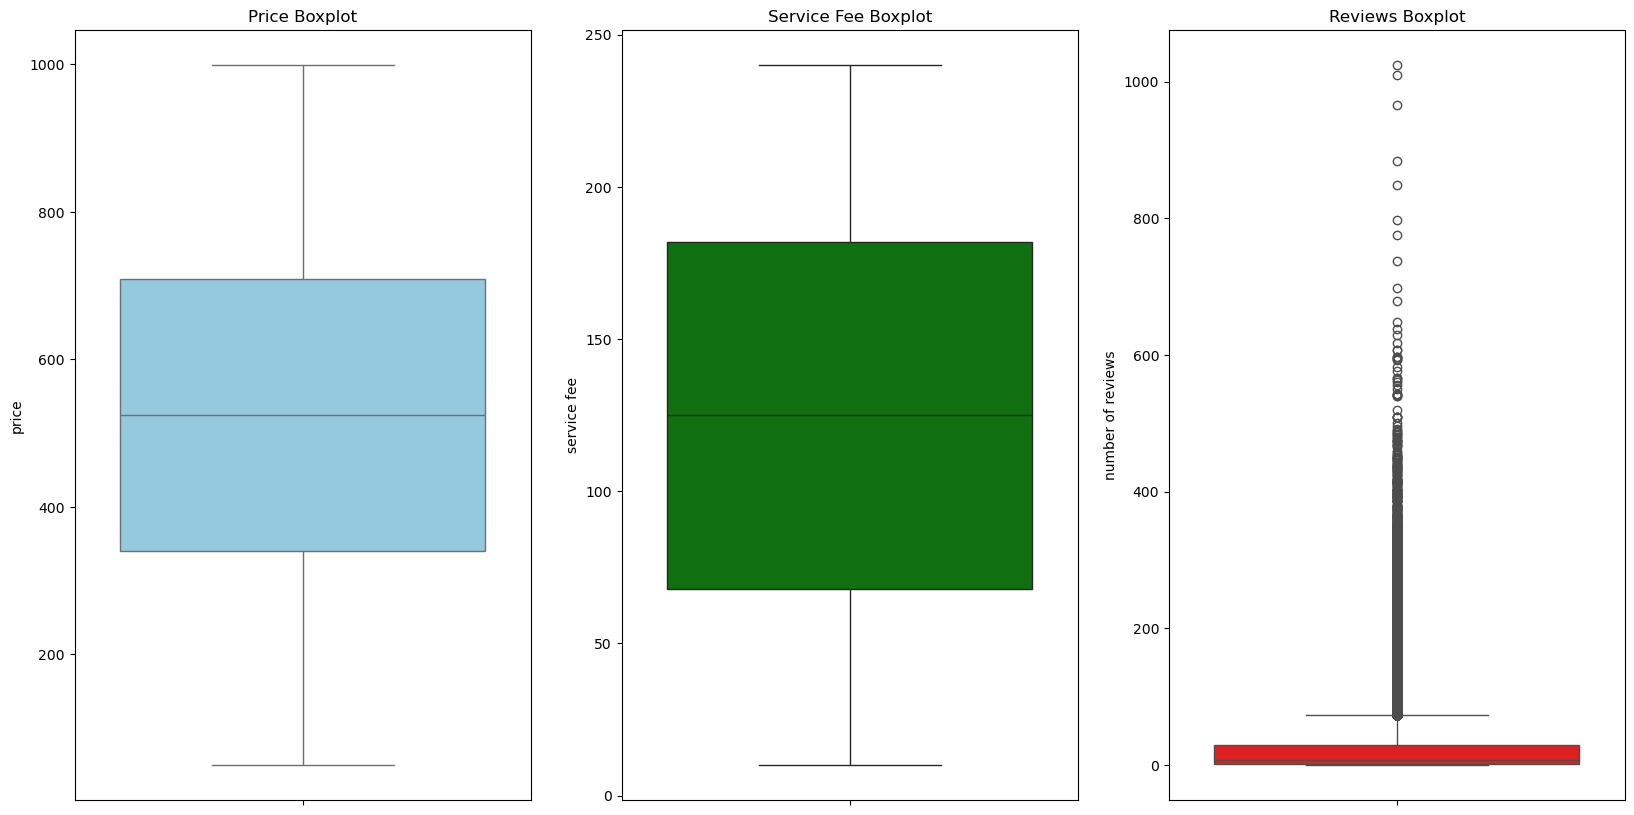

In [178]:
plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
sns.boxplot(y=df_newwee['price'],color='skyblue')
plt.title('Price Boxplot')

plt.subplot(1,3,2)
sns.boxplot(y=df_newwee['service fee'],color='green')
plt.title('Service Fee Boxplot')

plt.subplot(1,3,3)
sns.boxplot(y=df_newwee['number of reviews'],color='red')
plt.title('Reviews Boxplot')

plt.show()

Data Transformation 

In [179]:
numerical_columns

Index(['id', 'host id', 'lat', 'long', 'Construction year', 'price',
       'service fee', 'number of reviews', 'review rate number'],
      dtype='object')

In [180]:
df_newest.head(5)

,id,NAME,host id,host name,neighbourhood group,neighbourhood,lat,long,country,cancellation_policy,room type,Construction year,price,service fee,number of reviews,review rate number
0,1001254,Clean & quiet apt home by the park,80014485718,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,strict,Private room,2020.0,966.0,193.0,9.0,4.0
1,1002102,Skylit Midtown Castle,52335172823,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,moderate,Entire home/apt,2007.0,142.0,28.0,45.0,4.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,flexible,Private room,2005.0,620.0,124.0,0.0,5.0
3,1002755,Unknown,85098326012,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,moderate,Entire home/apt,2005.0,368.0,74.0,270.0,4.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,moderate,Entire home/apt,2009.0,204.0,41.0,9.0,3.0


In [181]:
df_newest['review rate number'].value_counts()

review rate number
5.0    23276
3.0    23260
4.0    23259
2.0    23045
1.0     9227
Name: count, dtype: int64

In [182]:
from sklearn.preprocessing import StandardScaler
def apply_scaling(df_newest,columns:list):
      scaler = StandardScaler()
      df_newest[columns] = scaler.fit_transform(df_newest[columns])
      return df_newest
  
columns = ['price','service fee']
df_newest = apply_scaling(df_newest,columns)

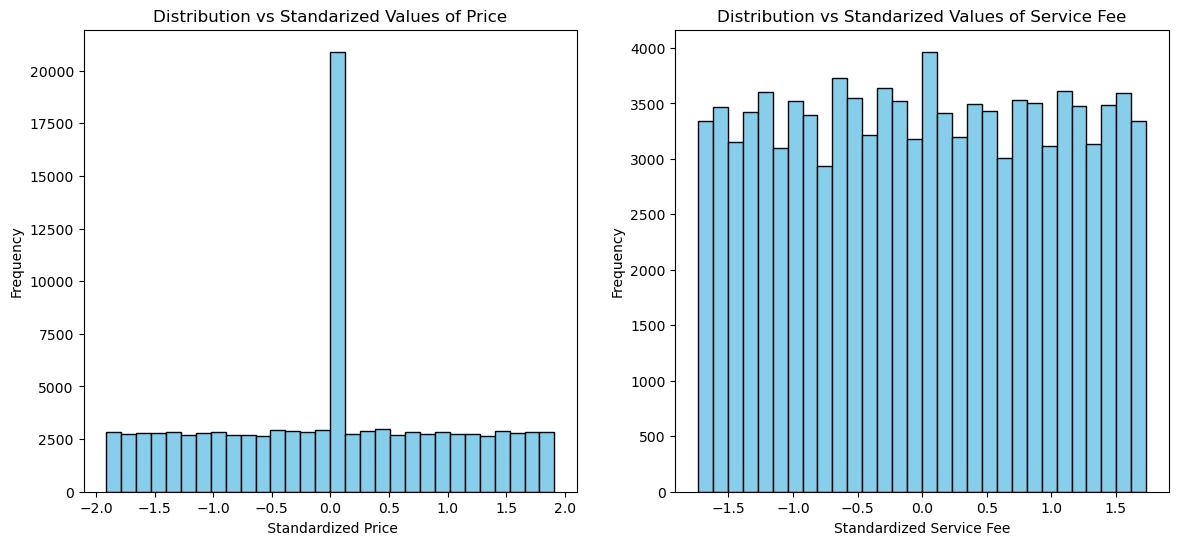

In [184]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

axes[0].hist(df_newest['price'],bins=30,color='skyblue',edgecolor = 'black')
axes[0].set_title("Distribution vs Standarized Values of Price")
axes[0].set_xlabel(" Standardized Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_newest['service fee'],bins=30,color='skyblue',edgecolor='black')
axes[1].set_title("Distribution vs Standarized Values of Service Fee")
axes[1].set_xlabel("Standardized Service Fee")
axes[1].set_ylabel('Frequency')
plt.show()
